# PCOS Detection - Stage 1: Clinical Model Training

Idhu notebook enna pannum:
1. Clinical (541) + Survey (465) datasets load + merge pannum (~899 records)
2. Data cleaning + preprocessing
3. Train/test split
4. XGBoost baseline model train pannum
5. Accuracy, Precision, Recall, F1, Confusion Matrix evaluate pannum
6. SHAP explainability apply pannum
7. Trained model-a `models/` folder la save pannum

**Run panna:** Ovvoru cell-a select pannitu `Shift + Enter` click pannunga, oru cell mudinjadhum next cell ku poganum.


## 1. Libraries Install + Import

In [9]:
# Idha first run pannunga (already install pannirundha skip aagum)
%pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn openpyxl --quiet

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load Datasets

**Important:** Path la spaces/brackets irukkura folder names (`archive (16)`) irundha, adha exact ah match pannunga.
Neenga unga `data/raw` folder la enna peru irukku nu paathu, keezha paths correct pannunga.

In [7]:
import os

RAW_DIR = "../data/raw"

# Automatically find the archive folders (handles spaces/brackets in names)
for item in sorted(os.listdir(RAW_DIR)):
    print(item)

archive (15)
archive (16)
archive (17)
archive (18)
archive (19)


In [8]:
# Adjust these paths if your folder names are different from what was printed above
CLINICAL_PATH = os.path.join(RAW_DIR, "archive (16)", "PCOS_data_without_infertility.xlsx")
SURVEY_PATH = os.path.join(RAW_DIR, "archive (19)", "CLEAN- PCOS SURVEY SPREADSHEET.csv")

clinical_df = pd.read_excel(CLINICAL_PATH, sheet_name="Full_new")
survey_df = pd.read_csv(SURVEY_PATH)

print("Clinical dataset shape:", clinical_df.shape)
print("Survey dataset shape:", survey_df.shape)

Clinical dataset shape: (541, 45)
Survey dataset shape: (465, 16)


In [9]:
clinical_df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [10]:
survey_df.head()

,Age (in Years),Weight (in Kg),Height (in Cm / Feet),Can you tell us your blood group ?,After how many months do you get your periods?\n(select 1- if every month/regular),Have you gained weight recently?,Do you have excessive body/facial hair growth ?,Are you noticing skin darkening recently?,Do have hair loss/hair thinning/baldness ?,Do you have pimples/acne on your face/jawline ?,Do you eat fast food regularly ?,Do you exercise on a regular basis ?,Have you been diagnosed with PCOS/PCOD?,Do you experience mood swings ?,Are your periods regular ?,"How long does your period last ? (in Days)\nexample- 1,2,3,4....."
0,21,47.0,168.0,13,1,0,0,0,0,0,0,0,0,1,1,6
1,21,45.0,156.0,11,1,0,0,1,1,1,0,0,0,1,1,4
2,17,37.0,162.0,15,1,0,0,0,0,1,1,0,0,1,1,6
3,28,54.0,160.0,15,1,0,0,0,0,0,0,0,0,1,1,4
4,45,40.0,150.0,13,2,0,0,0,1,0,0,0,1,1,0,7


## 3. Clean Column Names + Merge Datasets

In [12]:
# Clean column names (remove extra spaces)
clinical_df.columns = clinical_df.columns.str.strip()
survey_df.columns = survey_df.columns.str.strip()

# Drop junk/unnamed columns
clinical_df = clinical_df.loc[:, ~clinical_df.columns.str.contains("^Unnamed")]

print("Clinical columns:", list(clinical_df.columns))
print()
print("Survey columns:", list(survey_df.columns))

Clinical columns: ['Sl. No', 'Patient File No.', 'PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']

Survey columns: ['Age (in Years)', 'Weight (in Kg)', 'Height (in Cm / Feet)', 'Can you tell us your blood group ?', 'After how many months do you get your periods?\n(select 1- if every month/regular)', 'H

In [13]:
# Rename clinical dataset columns to common schema
clinical_common = clinical_df.rename(columns={
    "PCOS (Y/N)": "PCOS",
    "Age (yrs)": "Age",
    "Weight (Kg)": "Weight",
    "Cycle(R/I)": "Cycle_Regularity",
})
clinical_selected = clinical_common[["PCOS", "Age", "Weight", "BMI", "Cycle_Regularity"]].copy()
clinical_selected["Source"] = "Clinical_Dataset"

# Rename survey dataset columns to common schema
survey_selected = survey_df.rename(columns={
    "Have you been diagnosed with PCOS/PCOD?": "PCOS",
    "Age (in Years)": "Age",
    "Weight (in Kg)": "Weight",
    "Are your periods regular ?": "Cycle_Regularity",
})
if "BMI" not in survey_selected.columns:
    survey_selected["BMI"] = np.nan

def to_R_I(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().lower()
    if v in ["yes", "y", "1"]:
        return "R"
    if v in ["no", "n", "0"]:
        return "I"
    return val

survey_selected["Cycle_Regularity"] = survey_selected["Cycle_Regularity"].apply(to_R_I)
common_cols = [c for c in ["PCOS", "Age", "Weight", "BMI", "Cycle_Regularity"] if c in survey_selected.columns]
survey_selected = survey_selected[common_cols].copy()
survey_selected["Source"] = "Survey_Dataset"

print("Clinical selected:", clinical_selected.shape)
print("Survey selected:", survey_selected.shape)

Clinical selected: (541, 6)
Survey selected: (465, 6)


In [14]:
# Standardize PCOS label to 0/1
def standardize_label(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip().lower()
    if v in ["1", "y", "yes"]:
        return 1
    if v in ["0", "n", "no"]:
        return 0
    return np.nan

clinical_selected["PCOS"] = clinical_selected["PCOS"].apply(standardize_label)
survey_selected["PCOS"] = survey_selected["PCOS"].apply(standardize_label)

# Merge
combined_df = pd.concat([clinical_selected, survey_selected], ignore_index=True)
combined_df = combined_df.dropna(subset=["PCOS"])

print("Combined dataset shape:", combined_df.shape)
combined_df.head()

Combined dataset shape: (1006, 6)


,PCOS,Age,Weight,BMI,Cycle_Regularity,Source
0,0,28,44.6,19.300000,2,Clinical_Dataset
1,0,36,65.0,24.921163,2,Clinical_Dataset
2,1,33,68.8,25.270891,2,Clinical_Dataset
3,0,37,65.0,29.674945,2,Clinical_Dataset
4,0,25,52.0,20.060954,2,Clinical_Dataset


In [15]:
# Impute missing numeric values with median
numeric_cols = ["Age", "Weight", "BMI"]
for col in numeric_cols:
    combined_df[col] = pd.to_numeric(combined_df[col], errors="coerce")
    combined_df[col] = combined_df[col].fillna(combined_df[col].median())

combined_df = combined_df.drop_duplicates()

print("Final combined dataset shape:", combined_df.shape)
print()
print("Class distribution:")
print(combined_df["PCOS"].value_counts())

Final combined dataset shape: (899, 6)

Class distribution:
PCOS
0    627
1    272
Name: count, dtype: int64


In [16]:
# Save the merged dataset for later use
os.makedirs("../data/processed", exist_ok=True)
combined_df.to_csv("../data/processed/PCOS_combined_dataset.csv", index=False)
print("Saved to ../data/processed/PCOS_combined_dataset.csv")

Saved to ../data/processed/PCOS_combined_dataset.csv


## 4. Exploratory Data Analysis (Quick Check)

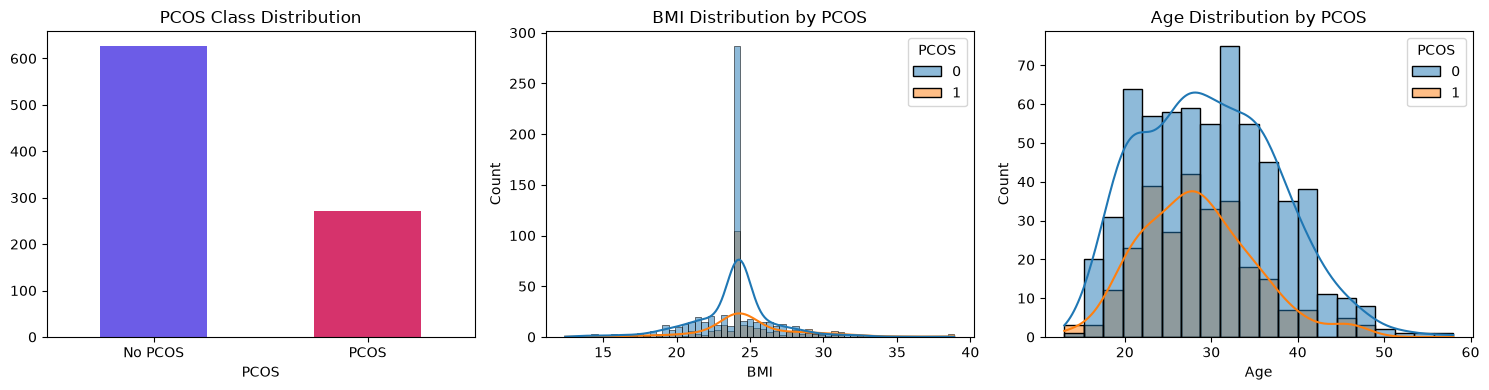

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

combined_df["PCOS"].value_counts().plot(kind="bar", ax=axes[0], color=["#6C5CE7", "#D6336C"])
axes[0].set_title("PCOS Class Distribution")
axes[0].set_xticklabels(["No PCOS", "PCOS"], rotation=0)

sns.histplot(data=combined_df, x="BMI", hue="PCOS", kde=True, ax=axes[1])
axes[1].set_title("BMI Distribution by PCOS")

sns.histplot(data=combined_df, x="Age", hue="PCOS", kde=True, ax=axes[2])
axes[2].set_title("Age Distribution by PCOS")

plt.tight_layout()
plt.show()

## 5. Prepare Features for Model Training

In [18]:
model_df = combined_df.copy()

# Encode Cycle_Regularity (R/I) to numeric
le = LabelEncoder()
model_df["Cycle_Regularity"] = model_df["Cycle_Regularity"].fillna("Unknown")
model_df["Cycle_Regularity"] = le.fit_transform(model_df["Cycle_Regularity"].astype(str))

X = model_df[["Age", "Weight", "BMI", "Cycle_Regularity"]]
y = model_df["PCOS"].astype(int)

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (899, 4)
Target distribution:
 PCOS
0    627
1    272
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (719, 4)
Test shape: (180, 4)


## 6. Train XGBoost Model

In [20]:
model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## 7. Evaluate Model

In [21]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No PCOS", "PCOS"]))

Accuracy:  0.7111
Precision: 0.5227
Recall:    0.4259
F1 Score:  0.4694
AUC-ROC:   0.6753

              precision    recall  f1-score   support

     No PCOS       0.77      0.83      0.80       126
        PCOS       0.52      0.43      0.47        54

    accuracy                           0.71       180
   macro avg       0.65      0.63      0.64       180
weighted avg       0.70      0.71      0.70       180



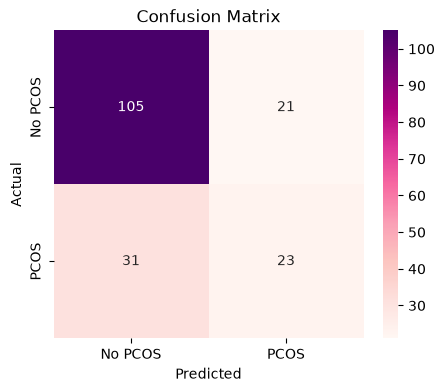

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu",
            xticklabels=["No PCOS", "PCOS"], yticklabels=["No PCOS", "PCOS"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

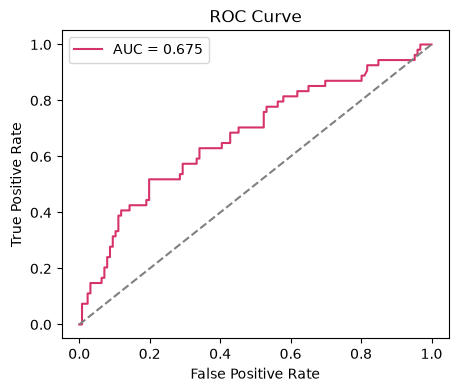

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="#D6336C", label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 8. Explainability with SHAP

Idhu unga **Stage 2 (Explainability)** ku direct ah use aagum — ovvoru feature (Age, BMI, Weight, Cycle) evlo mukkiyama prediction-a affect pannuchu nu kaatum.

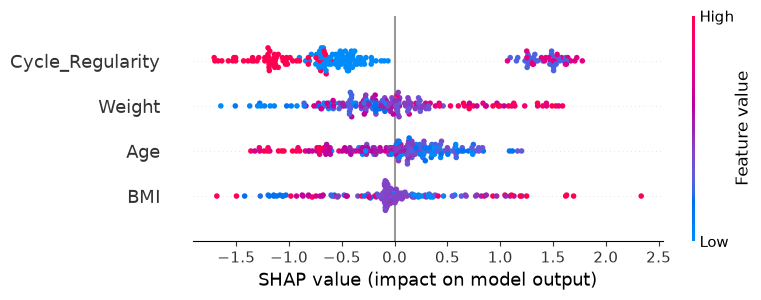

In [24]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=True)

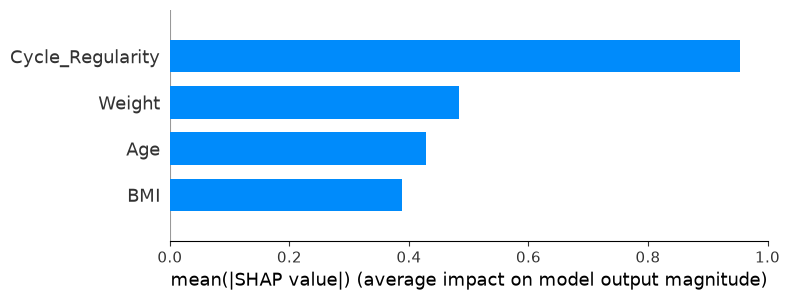

In [25]:
# Feature importance bar chart
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

## 9. Save the Trained Model

In [26]:
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(model, "../models/pcos_clinical_model.pkl")
joblib.dump(le, "../models/cycle_label_encoder.pkl")

print("Model saved to ../models/pcos_clinical_model.pkl")
print("Label encoder saved to ../models/cycle_label_encoder.pkl")

Model saved to ../models/pcos_clinical_model.pkl
Label encoder saved to ../models/cycle_label_encoder.pkl


## Next Steps

1. **Image branch**: Ultrasound images (`data/raw/archive (15)`) use panni CNN model separate ah train pannanum
2. **Fusion**: Rendu model output-a combine pannanum (decision-level fusion — simple weighted average)
3. **Grad-CAM**: Image model mela apply pannanum
4. **Flask integration**: Idha trained model-a `app/routes.py` la `/predict` route kulla load pannitu, dummy response-a real prediction-a maathanum
